Sizing Problem #3

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
MTOW=30000 #[lbm] note: PLACEHOLDER
C_d_min=0.028 # Taken from Gudmunsson Second Edition, Table 3-2 (page 62)
C_L_max_TO=1.9 # Value from Roskam, page 91
k=0.0428197399 # competively assessed
M_cruise=0.82 #cruise mach
alt=35000 #cruise altitude
take_off=5000 # [ft] landing and takeoff distance
take_off_alt=5000 #[ft] density altitude of takeoff
W_l=0.85*MTOW # landing weight


In [5]:
# cruise velocity constraint
a_35000=972.885 # ft/sec
rho_35000=0.000736627 # slug/ft^3
rho_5000=0.00204834 #slug/ft^3
rho_sl=0.00237717 # sea-level slug/ft^3
V_cruise=M_cruise*a_35000 #ft/sec
W_S=np.linspace(10, 100, 100) # linspace for wingload
q_cruise=0.5*rho_35000*V_cruise**2 # dynamic pressure at cruise
T_W_1=q_cruise*C_d_min*(1/W_S)+(k/q_cruise)*W_S # above line = valid


# takeoff constraint
TOP_25=5000/37.5 # Taken from Roskam, page 98
sigma_5000=np.sqrt(rho_5000/rho_sl) # normalizing density at 5000 ft (asl=0 ft)
T_W_2=W_S/(C_L_max_TO*sigma_5000*TOP_25) # Note, above line here

# landing constraint
V_approach=np.sqrt(5000/0.3)
#working here: 
#_stall_landing=
V_sl = V_approach/1.3 # page 111 roskam , in knots, need to convert to ft/sec
V_sl = V_sl*1.68781 # convert knots to ft/sec
C_L_max_L = 2.3 # page 91 roskam
W_S_landing = V_sl**2*rho_5000*0.5*C_L_max_L # rho mgiht be wrong units




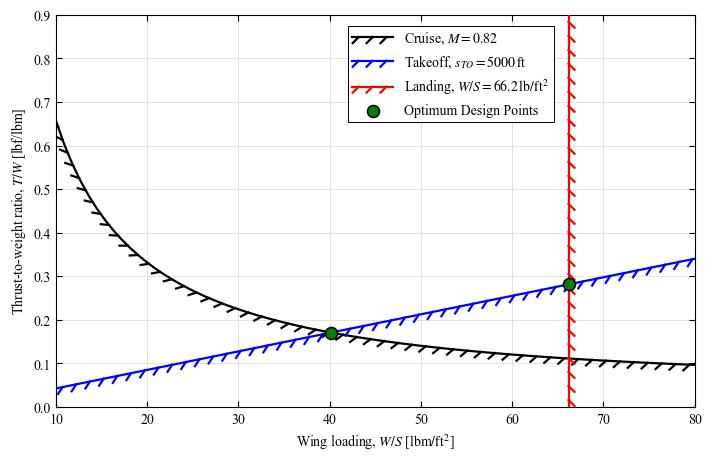

In [6]:
# AIAA-style constraint diagram
# The 7.0-in width is suitable for a two-column AIAA figure.
plt.rcParams.update({
    'font.family': 'times new roman',
    'font.serif': ['STIX Two Text', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 0.8,
})

# Design point 1: cruise/takeoff crossover (linear interpolation).
difference = T_W_1 - T_W_2
crossing_index = np.where(np.diff(np.sign(difference)) != 0)[0][0]
W_S_crossover = np.interp(
    0.0,
    difference[crossing_index:crossing_index + 2][::-1],
    W_S[crossing_index:crossing_index + 2][::-1],
)
T_W_crossover = np.interp(W_S_crossover, W_S, T_W_2)

# Design point 2: takeoff requirement at the landing wing-loading limit.
T_W_landing_design = np.interp(W_S_landing, W_S, T_W_2)

fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)

cruise_line, = ax.plot(
    W_S, T_W_1, color='black', lw=1.6,
    label=rf'Cruise, $M={M_cruise:.2f}$', zorder=3,
)
takeoff_line, = ax.plot(
    W_S, T_W_2, color='blue', lw=1.6,
    label=rf'Takeoff, $s_{{TO}}={take_off:.0f}\,\mathrm{{ft}}$', zorder=3,
)
landing_line = ax.axvline(
    W_S_landing, color='red', lw=1.6,
    label=rf'Landing, $W/S={W_S_landing:.1f}\,\mathrm{{lb/ft^2}}$', zorder=3,
)

# Add short feasibility ticks to every constraint boundary.
# Change angle from +135 to -135 to place ticks on the opposite side.
cruise_line.set_path_effects([
    pe.withTickedStroke(spacing=10, angle=135+270+180, length=0.6, foreground='black')
])
takeoff_line.set_path_effects([
    pe.withTickedStroke(spacing=10, angle=135+270+180, length=0.6, foreground='blue')
])
landing_line.set_path_effects([
    pe.withTickedStroke(spacing=10, angle=135+270+180, length=0.6, foreground='red')
])

# Mark and label both candidate design points.
ax.scatter(W_S_crossover, T_W_crossover, s=75, marker='o',
           facecolor='green', edgecolor='black', linewidth=1.1, zorder=6, label=rf'Optimum Design Points')


ax.scatter(W_S_landing, T_W_landing_design, s=75, marker='o',
           facecolor='green', edgecolor='black', linewidth=1.1, zorder=6)


ax.set_xlim(10, 80)
ax.set_ylim(0, 0.90)
ax.set_xlabel(r'Wing loading, $W/S$ [$\mathrm{lbm/ft^2}$]')
ax.set_ylabel(r'Thrust-to-weight ratio, $T/W$ [lbf/lbm]')
ax.set_xticks(np.linspace(10,80,8))
ax.set_yticks(np.arange(0.0, 1.0, 0.1))
ax.tick_params(which='both', direction='in', top=True, right=True,
               width=0.8, length=4)
ax.grid(True, which='major', color='0.87', linewidth=0.6, zorder=0)

legend = ax.legend(bbox_to_anchor=(.79, 0.85),
    loc='right', frameon=True, fancybox=False, framealpha=1.0,
    facecolor='white', edgecolor='black', borderpad=0.3, handlelength=3.0,
)
legend.get_frame().set_linewidth(0.7)

fig.savefig('sizing_constraint_diagram_AIAA.pdf', bbox_inches='tight')
fig.savefig('sizing_constraint_diagram_AIAA.png', dpi=600, bbox_inches='tight')
plt.show()